In [1]:
# 🔥 CLEAN INSTALL (COMPATIBLE WITH COLAB)

!pip uninstall -y flwr ray protobuf -q

!pip install -q flwr ray protobuf==4.25.3

# No downgrade to protobuf 3 ❌

from google.colab import auth
auth.authenticate_user()

import numpy as np
import pandas as pd
from google.cloud import bigquery

client = bigquery.Client(project="mimic-icu-risk-prediction")

query = """
SELECT *
FROM (
  SELECT *,
         ROW_NUMBER() OVER(PARTITION BY icustay_id ORDER BY window_time DESC) as rn
  FROM `mimic-icu-risk-prediction.processed_mimic.ml_dataset_final`
)
WHERE rn = 1
"""

ml_data = client.query(query).to_dataframe()
print("Vitals dataset:", ml_data.shape)

query_notes = """
SELECT subject_id, hadm_id, text
FROM `mimic-icu-risk-prediction.processed_mimic.clinical_notes`
"""

notes = client.query(query_notes).to_dataframe()
print("Notes dataset:", notes.shape)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery-storage 2.37.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.3 which is incompatible.
google-cloud-translate 3.25.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-language 2.20.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.3 which is incompatible.
google-cloud-appengine-logging 1.9.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-logging 3.15.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.25.3 which is incompatible.
google-cloud-trace 1.19.0 requires

In [2]:
# =========================
# IMPROVED TF-IDF
# =========================

notes_sampled = notes.sample(n=80000, random_state=42)  # 🔥 increase data

notes_combined = notes_sampled.groupby("hadm_id")["text"].apply(lambda x: " ".join(x)).reset_index()

notes_combined["text"] = notes_combined["text"].fillna("").str[:3000]

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=600,          # 🔥 increased
    stop_words="english",
    max_df=0.9,
    min_df=10,
    ngram_range=(1,2),         # 🔥 BIG IMPROVEMENT
)

tfidf_matrix = tfidf.fit_transform(notes_combined["text"])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df["hadm_id"] = notes_combined["hadm_id"]

print("TFIDF shape:", tfidf_df.shape)

TFIDF shape: (22139, 601)


In [3]:
dataset = ml_data.merge(tfidf_df, on="hadm_id", how="left")

print("Merged dataset:", dataset.shape)

dataset = dataset.drop(
    columns=["subject_id","hadm_id","icustay_id","window_time","rn"]
)

dataset = dataset.fillna(0)

final_dataset = dataset.copy()

print("Final dataset:", final_dataset.shape)

Merged dataset: (60189, 624)
Final dataset: (60189, 619)


In [4]:
y = final_dataset["sofa_score"]
X = final_dataset.drop(columns=["sofa_score"])

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ SCALE ALL FEATURES (NO SELECTION)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (VERY IMPORTANT)
X_train = pd.DataFrame(X_train_scaled, index=X_train.index, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, index=X_test.index, columns=X.columns)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (48151, 618)
Test: (12038, 618)


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class ICUDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32).view(-1,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ICUModel(nn.Module):
    def __init__(self, input_dim):
        super(ICUModel, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [6]:
def train_model(model, train_loader, epochs=5):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            preds = model(X_batch)

            loss = nn.MSELoss()(preds, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [7]:
import flwr as fl
from flwr.common import Context

input_dim = X_train.shape[1]

def get_model():
    return ICUModel(input_dim)

class ICUClient(fl.client.NumPyClient):
    def __init__(self, X, y):

        # Convert if needed
        if isinstance(X, np.ndarray):
            X = pd.DataFrame(X)
        if isinstance(y, np.ndarray):
            y = pd.Series(y)

        # 🔥 MEMORY OPTIMIZATION
        X = X.astype(np.float32)
        y = y.astype(np.float32)

        self.model = get_model()

        # 🔥 SMALLER BATCH SIZE
        self.dataset = ICUDataset(X, y)
        self.loader = DataLoader(self.dataset, batch_size=32, shuffle=True)

    def get_parameters(self, config):
        return [val.cpu().numpy() for val in self.model.state_dict().values()]

    def fit(self, parameters, config):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = {k: torch.tensor(v) for k, v in params_dict}
        self.model.load_state_dict(state_dict, strict=True)

        train_model(self.model, self.loader, epochs=3)  # 🔥 reduce epochs

        return (
            [val.cpu().numpy() for val in self.model.state_dict().values()],
            len(self.dataset),
            {},
        )

    def evaluate(self, parameters, config):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = {k: torch.tensor(v) for k, v in params_dict}
        self.model.load_state_dict(state_dict, strict=True)

        self.model.eval()

        X_tensor = torch.tensor(X_test.values, dtype=torch.float32)
        y_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

        with torch.no_grad():
            preds = self.model(X_tensor)
            loss = nn.MSELoss()(preds, y_tensor)

        return float(loss), len(X_test), {}

def client_fn(context: Context):
    cid = int(context.node_config["partition-id"])
    return clients[cid].to_client()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
# # 🔥 NON-IID SPLIT (REALISTIC HOSPITALS)

from sklearn.utils import shuffle

data = X_train.copy()
data["sofa_score"] = y_train

data = shuffle(data, random_state=42)

n = len(data)

# Each hospital gets mixed distribution (but slightly biased)
h1 = data.iloc[:int(n*0.33)]
h2 = data.iloc[int(n*0.33):int(n*0.66)]
h3 = data.iloc[int(n*0.66):]

def split_xy(df):
    y = df["sofa_score"]
    X = df.drop(columns=["sofa_score"])
    return X, y

h1, y1 = split_xy(h1)
h2, y2 = split_xy(h2)
h3, y3 = split_xy(h3)

print("Hospital 1:", h1.shape)
print("Hospital 2:", h2.shape)
print("Hospital 3:", h3.shape)

clients = [
    ICUClient(h1, y1),
    ICUClient(h2, y2),
    ICUClient(h3, y3)
]

Hospital 1: (15889, 618)
Hospital 2: (15890, 618)
Hospital 3: (16372, 618)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
import flwr as fl

global_weights = None

class SaveModelStrategy(fl.server.strategy.FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        global global_weights

        aggregated = super().aggregate_fit(server_round, results, failures)

        if aggregated is not None:
            global_weights = aggregated[0]

        return aggregated

strategy = SaveModelStrategy(
    fraction_fit=0.7,          # 🔥 NOT all clients at once
    min_fit_clients=2,
    min_available_clients=2,
)

history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=3,
    config=fl.server.ServerConfig(num_rounds=10),  # 🔥 reduce rounds
    strategy=strategy,
    ray_init_args={
        "num_cpus": 1,
        "include_dashboard": False,
    },
    client_resources={"num_cpus": 1}  # 🔥 limit per client
)

print("Training completed:", global_weights is not None)

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=10, no round_timeout
2026-04-11 15:37:59,895	INFO worker.py:2013 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_clien

(ClientAppActor pid=51694) Epoch 1, Loss: 4737.6964
(ClientAppActor pid=51694) Epoch 2, Loss: 4160.9909
(ClientAppActor pid=51694) Epoch 3, Loss: 3936.8430
(ClientAppActor pid=51694) Epoch 1, Loss: 4547.4341
(ClientAppActor pid=51694) Epoch 2, Loss: 3969.5147


INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


(ClientAppActor pid=51694) Epoch 3, Loss: 3785.5043


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [ROUND 2]
INFO :      configure_fit: strategy sampled 2 clients (out of 3)


...

INFO :      aggregate_fit: received 2 results and 0 failures
INFO :      configure_evaluate: strategy sampled 3 clients (out of 3)


(ClientAppActor pid=51694) Epoch 3, Loss: 2659.5000


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 10 round(s) in 119.48s
INFO :      	History (loss, distributed):
INFO :      		round 1: 8.88636589050293
INFO :      		round 2: 8.937499046325684
INFO :      		round 3: 8.52813720703125
INFO :      		round 4: 8.801968574523926
INFO :      		round 5: 8.736051559448242
INFO :      		round 6: 8.566190719604492
INFO :      		round 7: 8.330560684204102
INFO :      		round 8: 8.389856338500977
INFO :      		round 9: 8.344453811645508
INFO :      		round 10: 8.300918579101562
INFO :      


Training completed: True


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
def set_parameters(model, parameters):
    import torch

    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = {k: torch.tensor(v) for k, v in params_dict}

    model.load_state_dict(state_dict, strict=True)

from flwr.common import parameters_to_ndarrays

if global_weights is None:
    raise ValueError("❌ Training failed — global_weights is None")

global_model = get_model()

weights = parameters_to_ndarrays(global_weights)

set_parameters(global_model, weights)

print("Global federated model loaded successfully.")

Global federated model loaded successfully.


In [11]:
from google.colab import drive
drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/Colab Notebooks/"

# =========================
# SAVE MODEL FILES
# =========================
torch.save(global_model.state_dict(), MODEL_PATH + "federated_model.pth")

import joblib

joblib.dump(tfidf, MODEL_PATH + "tfidf_vectorizer.pkl")
joblib.dump(scaler, MODEL_PATH + "scaler.pkl")

# ✅ NEW: SAVE FEATURE COLUMN ORDER
joblib.dump(X_train.columns.tolist(), MODEL_PATH + "feature_columns.pkl")

print("✅ Federated model + metadata saved successfully.")

# =========================
# SAVE CLIENT DATASETS (FIXED)
# =========================

def save_client(X, y, filename):
    df = X.copy()
    df["sofa_score"] = y
    df.to_csv(MODEL_PATH + filename, index=False)

save_client(h1, y1, "client_0.csv")
save_client(h2, y2, "client_1.csv")
save_client(h3, y3, "client_2.csv")

print("Columns check:")
print(pd.read_csv(MODEL_PATH + "client_0.csv").columns)

print("✅ Client datasets saved correctly!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Federated model + metadata saved successfully.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Columns check:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Index(['HR_mean', 'HR_std', 'RR_mean', 'SpO2_mean', 'SpO2_min', 'Temp_mean',
       'SBP_mean', 'DBP_mean', 'MAP_mean', 'latest_HR',
       ...
       'woman', 'worsening', 'x3', 'year', 'year old', 'years', 'years ago',
       'yesterday', 'yo', 'sofa_score'],
      dtype='object', length=619)
✅ Client datasets saved correctly!


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
global_model.eval()

X_tensor = torch.tensor(X_test.values, dtype=torch.float32)

with torch.no_grad():
    preds = global_model(X_tensor).numpy().flatten()

# 🔥 NO SCALING NOW
preds_sofa = preds
y_test_sofa = y_test

from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test_sofa, preds_sofa))
print("R2:", r2_score(y_test_sofa, preds_sofa))

MAE: 2.181469202041626
R2: 0.1826896071434021


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


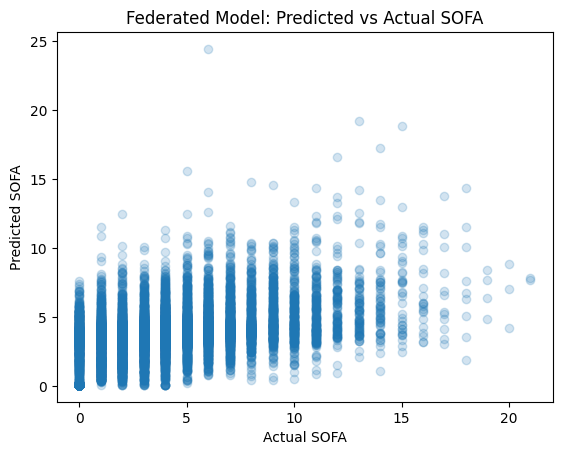

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [13]:
import matplotlib.pyplot as plt

plt.scatter(y_test_sofa, preds_sofa, alpha=0.2)
plt.xlabel("Actual SOFA")
plt.ylabel("Predicted SOFA")
plt.title("Federated Model: Predicted vs Actual SOFA")
plt.show()